#### 과일 Data 를 CNN 으로 Image 분류\

In [1]:
import numpy as np

fruits = np.load('../Data/fruits.npy')
fruits.shape

(300, 100, 100)

In [2]:
# Target 만들기
target = np.concatenate(
    [
        np.zeros(100), # Apple
        np.ones(100), # Pineapple
        np.full(100, 2) # banana
    ]
)

target.shape

(300,)

> shape 는 함수 아니라는 거 알고있기! - 더러운 문제로 출제 된 적 있음.

In [11]:
target

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 2., 2., 2., 2.,
       2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.,
       2., 2., 2., 2., 2.

---
#### train 과 test

In [20]:
from sklearn.model_selection import train_test_split

train = fruits.reshape(-1, 100, 100, 1)
# CNN 은 이미지 데이터를 학습하기 때문에 DataSet에 채널차원이 꼭 필요하다 -> reshape()함수에서 (1) 속성값

train_data, test_data, train_target, test_target = \
    train_test_split(
        train,
        target,
        test_size=0.2,
        random_state=42
    )

In [21]:
# 크기 확인
print(train_data.shape)
print(test_data.shape)
print(train_target.shape)
print(test_target.shape)

(240, 100, 100, 1)
(60, 100, 100, 1)
(240,)
(60,)


#### CNN 만들기

Epoch 1/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 156ms/step - accuracy: 0.5156 - loss: 1.0606 - val_accuracy: 0.9375 - val_loss: 0.5650
Epoch 2/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 129ms/step - accuracy: 0.9375 - loss: 0.4067 - val_accuracy: 1.0000 - val_loss: 0.1211
Epoch 3/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 131ms/step - accuracy: 0.9844 - loss: 0.0950 - val_accuracy: 1.0000 - val_loss: 0.0094
Epoch 4/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 129ms/step - accuracy: 0.9948 - loss: 0.0257 - val_accuracy: 1.0000 - val_loss: 0.0020
Epoch 5/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 94ms/step - accuracy: 0.9948 - loss: 0.0109 - val_accuracy: 1.0000 - val_loss: 0.0026
Epoch 6/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 133ms/step - accuracy: 1.0000 - loss: 0.0104 - val_accuracy: 1.0000 - val_loss: 2.3880e-04
Epoch 7/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 129ms/step - accuracy: 1.0000 - loss: 0.0033 - val_accuracy: 1.0000 - val_loss: 8.0552e-05
Epoch 8/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 134ms/step - accuracy: 1.0000 - loss: 0.0040 - val_accuracy: 1.0000 - va

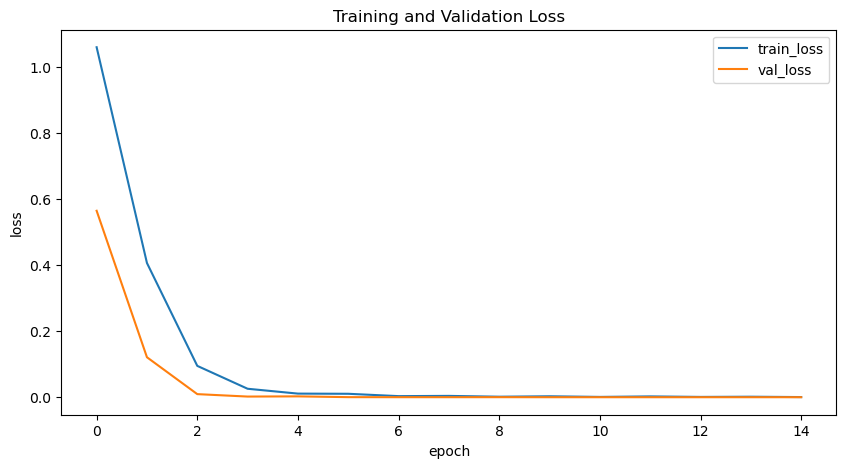

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 1.0000 - loss: 1.4643e-05
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
예측한 레이블: 2
실제 레이블: 2.0

🥇 최적의 에포크: 13 epoch
--------------------------------------------------
📈 [Train]       훈련 정확도: 100.00%
🧪 [Validation]  검증 정확도: 100.00%
🎯 [Test]        🎯 최종 테스트 정확도: 100.00%


In [22]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow import keras

# 1. 데이터 불러오기 및 전처리
# (train_input, train_target), (test_input, test_target) = (
#     keras.datasets.fashion_mnist.load_data()
# )

# 픽셀값을 0~1 사이로 정규화하고 채널 차원(1) 추가
train_scaled = train_data.reshape(-1, 100, 100, 1) / 255.0
test_scaled = test_data.reshape(-1, 100, 100, 1) / 255.0

# 검증 세트 분리
train_scaled, val_scaled, train_target, val_target = train_test_split(
    train_scaled, train_target, test_size=0.2, random_state=42
)

# 2. CNN 모델 구축
model = keras.Sequential(
    [
        # 합성곱 층 1
        keras.layers.Conv2D(
            32,
            kernel_size=3,
            activation="relu",
            padding="same",
            input_shape=(100, 100, 1),
        ),
        keras.layers.MaxPooling2D(2),
        # 합성곱 층 2
        keras.layers.Conv2D(
            64, kernel_size=3, activation="relu", padding="same"
        ),
        keras.layers.MaxPooling2D(2),
        # 1차원으로 펼치기
        keras.layers.Flatten(),
        # 은닉층
        keras.layers.Dense(100, activation="relu"),
        # 드롭아웃 (과대적합 방지)
        keras.layers.Dropout(0.5),
        # 출력층
        keras.layers.Dense(3, activation="softmax"),
    ]
)

# 모델 컴파일
model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"],
)

# 3. 콜백 설정 및 모델 학습
checkpoint_cb = keras.callbacks.ModelCheckpoint(
    "../Note_DL/best_cnn_model.keras", save_best_only=True
)
early_stopping_cb = keras.callbacks.EarlyStopping(
    patience=2, restore_best_weights=True
)

history = model.fit(
    train_scaled,
    train_target,
    epochs=20,
    validation_data=(val_scaled, val_target),
    callbacks=[checkpoint_cb, early_stopping_cb],
)

# 4. 학습 결과 시각화 (손실 그래프)
plt.figure(figsize=(10, 5))
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.title("Training and Validation Loss")
plt.show()

# 5. 테스트 세트 모델 평가
model.evaluate(test_scaled, test_target)

# 6. 테스트 세트 첫 번째 이미지 예측 결과 확인
predictions = model.predict(test_scaled)
predicted_label = np.argmax(predictions[0])
actual_label = test_target[0]

print(f"예측한 레이블: {predicted_label}")
print(f"실제 레이블: {actual_label}")

# 7. 최적의 에포크 인덱스 찾기 (검증 손실이 가장 낮았던 시점 기준)
val_loss_list = history.history['val_loss'] # -> model.fit() 함수 실행 결과가 자동으로 history 딕셔너리 변수에 저장됨. 해당 변수에 loss, accuracy, val_loss, val_accuracy 등이 저장됨.
best_epoch_index = np.argmin(val_loss_list) # 리스트 인덱스 (0부터 시작)
best_epoch = best_epoch_index + 1               # 실제 에포크 차수 (1부터 시작)

# 8. 최적 에포크 시점의 Train 및 Valid 정확도 추출
best_train_accuracy = history.history['accuracy'][best_epoch]
best_val_accuracy = history.history['val_accuracy'][best_epoch]

# 9. 가장 성능이 좋았던 저장된 모델을 불러와 Test 정확도 측정
best_model = keras.models.load_model('best_cnn_model.keras')
test_loss, best_test_accuracy = best_model.evaluate(test_scaled, test_target, verbose=0)

# 10. 최종 결과 출력
print("\n" + "="*50)
print(f"🥇 최적의 에포크: {best_epoch} epoch")
print("-"*50)
print(f"📈 [Train]       훈련 정확도: {best_train_accuracy * 100:.2f}%")
print(f"🧪 [Validation]  검증 정확도: {best_val_accuracy * 100:.2f}%")
print(f"🎯 [Test]        🎯 최종 테스트 정확도: {best_test_accuracy * 100:.2f}%")
print("="*50)

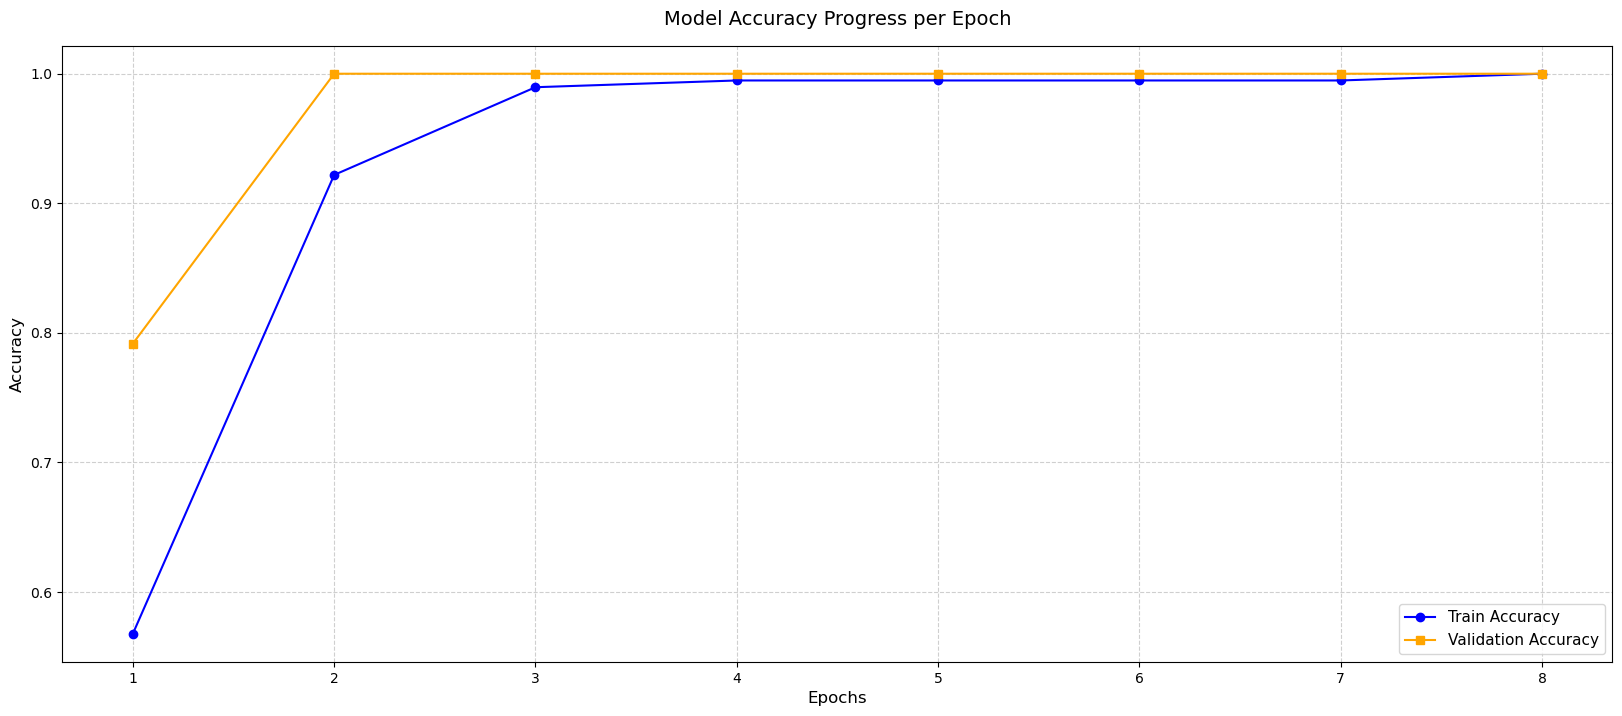

In [19]:
import matplotlib.pyplot as plt

# 1. history 객체에서 에포크별 train, valid 정확도 리스트 추출
train_acc_list = history.history['accuracy']
valid_acc_list = history.history['val_accuracy']

# 2. 에포크 수를 기준으로 x축 설정 (1부터 시작)
epochs_range = range(1, len(train_acc_list) + 1)

# 3. 그래프 그리기
plt.figure(figsize=(20, 8)) # 그래프 크기 설정
plt.plot(epochs_range, train_acc_list, label='Train Accuracy', marker='o', color='blue')
plt.plot(epochs_range, valid_acc_list, label='Validation Accuracy', marker='s', color='orange')

# 4. 그래프 꾸미기 (제목, 축 레이블, 범례 등)
plt.title('Model Accuracy Progress per Epoch', fontsize=14, pad=15)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.xticks(epochs_range) # x축 눈금을 에포크 정수로 고정
plt.grid(True, linestyle='--', alpha=0.6) # 배경 격자 추가
plt.legend(loc='lower right', fontsize=11) # 범례 위치 설정

# 5. 화면에 그래프 출력
plt.show()